In [1]:
# Install opendatasets to download from Kaggle
!pip install opendatasets --quiet

import opendatasets as od
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report
from google.colab import files

# Download the dataset (skip if already downloaded)
od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: eitharmoutasim
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:01<00:00, 124MB/s] 



Using device: cpu


Data Transformations & Custom Dataset Class

In [6]:
# Data transformations (Standard ImageNet normalization + augmentations)
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

class BeanLeafDataset(Dataset):
    def __init__(self, root_dir, csv_path, transform=None):
        self.transform = transform
        self.img_paths = []
        self.labels = []

        # Strip trailing slashes to ensure consistent path handling
        root_dir = root_dir.rstrip('/')

        # Read CSV
        df = pd.read_csv(csv_path)
        print(f"Loaded CSV: {csv_path} with {len(df)} rows.")

        # Identify columns (handle potential variations in column names)
        img_col = 'image:FILE' if 'image:FILE' in df.columns else 'image'
        cat_col = 'category'

        # Normalize categories and build maps for fast lookup
        label_map_basename = {}
        label_map_fullpath = {}

        for _, row in df.iterrows():
            img_path_csv = str(row[img_col])
            cat_val = row[cat_col]
            if pd.isna(cat_val): continue # Skip empty rows

            # Normalize category: lowercase, replace spaces with underscores
            category = str(cat_val).strip().lower().replace(' ', '_')
            label_map_fullpath[img_path_csv] = category
            label_map_basename[os.path.basename(img_path_csv)] = category

        # Dynamically find classes from the CSV to avoid hardcoded mismatches
        unique_classes = sorted(list(set(label_map_fullpath.values())))
        print(f"Classes found in CSV: {unique_classes}")
        self.class_to_idx = {c: i for i, c in enumerate(unique_classes)}
        self.idx_to_class = {i: c for i, c in enumerate(unique_classes)}

        # Walk through the root directory to find all images
        if not os.path.exists(root_dir):
            print(f"Error: Root directory {root_dir} does not exist!")
            return

        for subdir, _, files in os.walk(root_dir):
            for img_name in files:
                # Filter out non-image files just in case
                if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue

                img_path = os.path.join(subdir, img_name)
                category = None

                # 1. Try exact match with relative path (Most reliable)
                rel_path = os.path.relpath(img_path, os.path.dirname(root_dir))
                if rel_path in label_map_fullpath:
                    category = label_map_fullpath[rel_path]
                # 2. Try matching just the basename
                elif img_name in label_map_basename:
                    category = label_map_basename[img_name]
                else:
                    # 3. Fallback: check if any CSV path ends with the image name
                    for k, v in label_map_fullpath.items():
                        if k.endswith(img_name):
                            category = v
                            break

                if category and category in self.class_to_idx:
                    self.img_paths.append(img_path)
                    self.labels.append(self.class_to_idx[category])

        print(f"Successfully matched {len(self.img_paths)} images in {root_dir}.")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, label

Prepare DataLoaders

In [7]:
# Just pass the root directories! The Dataset class will automatically find all subfolders.
train_root = '/content/bean-leaf-lesions-classification/train'
val_root = '/content/bean-leaf-lesions-classification/val'

train_dataset = BeanLeafDataset(train_root, '/content/bean-leaf-lesions-classification/train.csv', data_transforms['train'])
val_dataset = BeanLeafDataset(val_root, '/content/bean-leaf-lesions-classification/val.csv', data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"\nTraining samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Loaded CSV: /content/bean-leaf-lesions-classification/train.csv with 1034 rows.
Classes found in CSV: ['0', '1', '2']
Successfully matched 1034 images in /content/bean-leaf-lesions-classification/train.
Loaded CSV: /content/bean-leaf-lesions-classification/val.csv with 133 rows.
Classes found in CSV: ['0', '1', '2']
Successfully matched 133 images in /content/bean-leaf-lesions-classification/val.

Training samples: 1034
Validation samples: 133


Model Definition & Freezing Strategy

In [8]:
# Load Pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers initially
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer for our classes
num_ftrs = model.fc.in_features
num_classes = len(train_dataset.class_to_idx) # Dynamically get number of classes
model.fc = nn.Linear(num_ftrs, num_classes)

# Move to device
model = model.to(device)

# Define Loss Function
criterion = nn.CrossEntropyLoss()

# Phase 1 Optimizer: Train ONLY the new FC layer
optimizer_fc = optim.Adam(model.fc.parameters(), lr=0.001)

# Phase 2 Setup: Unfreeze layer3 and layer4 for fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.layer3.parameters():
    param.requires_grad = True

# Phase 2 Optimizer: Differential learning rates (smaller for backbone, larger for head)
optimizer_finetune = optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-5},
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(), 'lr': 1e-4}
])

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 68.2MB/s]


Training Loop & Execution

In [9]:
def train_model(model, criterion, optimizer, num_epochs=10):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                loader = train_loader
            else:
                model.eval()
                loader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc = running_corrects.double() / len(loader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
        print()
    return history

# Execute Phase 1: Train FC layer
print("Phase 1: Training the new Fully Connected layer...")
history_fc = train_model(model, criterion, optimizer_fc, num_epochs=5)

# Execute Phase 2: Fine-tune later layers
print("Phase 2: Fine-tuning the later layers...")
history_finetune = train_model(model, criterion, optimizer_finetune, num_epochs=10)

# Combine histories for plotting
history = {
    'train_loss': history_fc['train_loss'] + history_finetune['train_loss'],
    'train_acc': history_fc['train_acc'] + history_finetune['train_acc'],
    'val_loss': history_fc['val_loss'] + history_finetune['val_loss'],
    'val_acc': history_fc['val_acc'] + history_finetune['val_acc']
}

Phase 1: Training the new Fully Connected layer...
Epoch 1/5
--------------------
train Loss: 0.9330 Acc: 0.5503
val Loss: 0.7136 Acc: 0.7068

Epoch 2/5
--------------------
train Loss: 0.7081 Acc: 0.7205
val Loss: 0.6478 Acc: 0.6917

Epoch 3/5
--------------------
train Loss: 0.6057 Acc: 0.7650
val Loss: 0.5126 Acc: 0.8195

Epoch 4/5
--------------------
train Loss: 0.5404 Acc: 0.8162
val Loss: 0.4850 Acc: 0.8045

Epoch 5/5
--------------------
train Loss: 0.5152 Acc: 0.8037
val Loss: 0.4446 Acc: 0.8346

Phase 2: Fine-tuning the later layers...
Epoch 1/10
--------------------
train Loss: 0.4692 Acc: 0.8114
val Loss: 0.3600 Acc: 0.8947

Epoch 2/10
--------------------
train Loss: 0.3819 Acc: 0.8675
val Loss: 0.3153 Acc: 0.9023

Epoch 3/10
--------------------
train Loss: 0.3610 Acc: 0.8627
val Loss: 0.2331 Acc: 0.9323

Epoch 4/10
--------------------
train Loss: 0.2919 Acc: 0.9014
val Loss: 0.1939 Acc: 0.9474

Epoch 5/10
--------------------
train Loss: 0.2799 Acc: 0.8956
val Loss: 0.2

Training Report (Loss and Accuracy Curves)

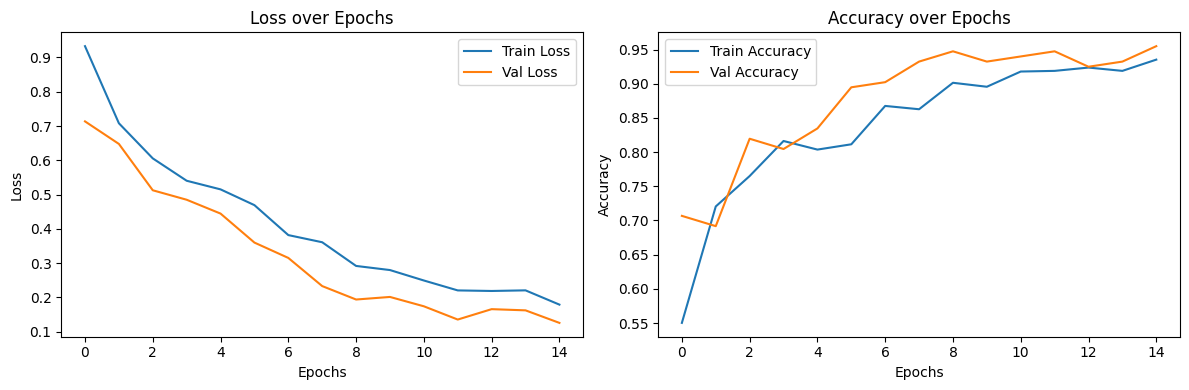

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Test Accuracy Score

In [11]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report on Validation Set:")
print(classification_report(all_labels, all_preds, target_names=list(train_dataset.class_to_idx.keys())))


Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      0.86      0.93        44
           2       0.88      1.00      0.94        45

    accuracy                           0.95       133
   macro avg       0.96      0.95      0.95       133
weighted avg       0.96      0.95      0.95       133



In [18]:
torch.save(model.state_dict(), "bean_leaf_model.pth")

Live Inference Demo

In [21]:
import gradio as gr
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Class Names
# Replace with your actual classes
# -----------------------------
class_names = [
    "angular_leaf_spot",
    "bean_rust",
    "healthy"
]

# -----------------------------
# Load Model
# -----------------------------
model = models.resnet18(weights=None)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

model.load_state_dict(
    torch.load("bean_leaf_model.pth", map_location=device)
)

model.to(device)
model.eval()

# -----------------------------
# Image Transform
# -----------------------------
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# -----------------------------
# Prediction Function
# -----------------------------
def predict_leaf(image):

    image = image.convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)

        probs = torch.softmax(outputs, dim=1)[0]

        prediction = class_names[
            torch.argmax(probs).item()
        ]

    return {
        class_names[i]: float(probs[i])
        for i in range(len(class_names))
    }

# -----------------------------
# Gradio Interface
# -----------------------------
demo = gr.Interface(
    fn=predict_leaf,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="🌱 Bean Leaf Disease Detector",
    description="""
Upload a bean leaf image and the model will predict
whether it is Healthy, Bean Rust, or Angular Leaf Spot.
"""
)

if __name__ == "__main__":
    demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cd8af99f63595b453d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
